In [83]:
####################
#Objective
#######################

#This project analyzes customer-level marketing campaign data from a retail company.
#The goal is to identify meaningful customer segments based on demographics, product spending, purchase behavior, and campaign engagement.
#We use PCA to reduce the number of behavioral variables into interpretable dimensions, and clustering to group customers into actionable segments. #
#The final objective is to recommend targeted marketing strategies for each segment.

In [84]:
import pandas as pd

url = "https://raw.githubusercontent.com/arienugroho050396/Customer-Personality-Analysis/main/marketing_campaign.csv"
df = pd.read_csv(url, sep="\t")
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,4,0,0,0,0,0,0,3,11,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,6,0,0,0,0,0,0,3,11,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,5,0,0,0,0,0,0,3,11,0


In [85]:
#Running checks

df.shape
df.info()
df.isnull().sum()
df.describe()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 29 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   2240 non-null   int64  
 1   Year_Birth           2240 non-null   int64  
 2   Education            2240 non-null   object 
 3   Marital_Status       2240 non-null   object 
 4   Income               2216 non-null   float64
 5   Kidhome              2240 non-null   int64  
 6   Teenhome             2240 non-null   int64  
 7   Dt_Customer          2240 non-null   object 
 8   Recency              2240 non-null   int64  
 9   MntWines             2240 non-null   int64  
 10  MntFruits            2240 non-null   int64  
 11  MntMeatProducts      2240 non-null   int64  
 12  MntFishProducts      2240 non-null   int64  
 13  MntSweetProducts     2240 non-null   int64  
 14  MntGoldProds         2240 non-null   int64  
 15  NumDealsPurchases    2240 non-null   i

,ID,Year_Birth,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
count,2240.000000,2240.000000,2216.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,...,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.0,2240.0,2240.000000
mean,5592.159821,1968.805804,52247.251354,0.444196,0.506250,49.109375,303.935714,26.302232,166.950000,37.525446,...,5.316518,0.072768,0.074554,0.072768,0.064286,0.013393,0.009375,3.0,11.0,0.149107
std,3246.662198,11.984069,25173.076661,0.538398,0.544538,28.962453,336.597393,39.773434,225.715373,54.628979,...,2.426645,0.259813,0.262728,0.259813,0.245316,0.114976,0.096391,0.0,0.0,0.356274
min,0.000000,1893.000000,1730.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
25%,2828.250000,1959.000000,35303.000000,0.000000,0.000000,24.000000,23.750000,1.000000,16.000000,3.000000,...,3.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
50%,5458.500000,1970.000000,51381.500000,0.000000,0.000000,49.000000,173.500000,8.000000,67.000000,12.000000,...,6.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
75%,8427.750000,1977.000000,68522.000000,1.000000,1.000000,74.000000,504.250000,33.000000,232.000000,50.000000,...,7.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
max,11191.000000,1996.000000,666666.000000,2.000000,2.000000,99.000000,1493.000000,199.000000,1725.000000,259.000000,...,20.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,3.0,11.0,1.000000


In [86]:
#Handling missing values


#Income was the only variable with missing values.
#Since only 24 observations had missing income values, representing a small share of the dataset, we are removing  those rows instead of imputing income.
#Income is an important segmentation variable, and imputing it could introduce artificial similarity between customers.


df_clean = df.copy()
df_clean = df_clean.dropna(subset=["Income"])
df_clean = df_clean.drop_duplicates()

print(df.shape)
df_clean.shape

(2240, 29)


(2216, 29)

In [87]:
#Converting date columns to datetime

df_clean["Dt_Customer"] = pd.to_datetime(df_clean["Dt_Customer"], dayfirst=True)
df_clean["Dt_Customer"].head()

,Dt_Customer
0,2012-09-04
1,2014-03-08
2,2013-08-21
3,2014-02-10
4,2014-01-19


In [88]:
# Create aggregate and additional marketing variables

analysis_year = df_clean["Dt_Customer"].dt.year.max()

df_clean["Age"] = analysis_year - df_clean["Year_Birth"]

df_clean["Children"] = df_clean["Kidhome"] + df_clean["Teenhome"]

df_clean["TotalSpend"] = (
    df_clean["MntWines"] +
    df_clean["MntFruits"] +
    df_clean["MntMeatProducts"] +
    df_clean["MntFishProducts"] +
    df_clean["MntSweetProducts"] +
    df_clean["MntGoldProds"]
)

df_clean["TotalPurchases"] = (
    df_clean["NumWebPurchases"] +
    df_clean["NumCatalogPurchases"] +
    df_clean["NumStorePurchases"]
)

reference_date = df_clean["Dt_Customer"].max()

df_clean["CustomerTenureDays"] = (
    reference_date - df_clean["Dt_Customer"]
).dt.days

df_clean["TotalCampaignAccepted"] = (
    df_clean["AcceptedCmp1"] +
    df_clean["AcceptedCmp2"] +
    df_clean["AcceptedCmp3"] +
    df_clean["AcceptedCmp4"] +
    df_clean["AcceptedCmp5"] +
    df_clean["Response"]
)

In [89]:
#Checking outliers and general check for new columns

df_clean[
    [
        "Income",
        "Age",
        "Children",
        "TotalSpend",
        "TotalPurchases",
        "CustomerTenureDays",
        "TotalCampaignAccepted"
    ]
].describe()

,Income,Age,Children,TotalSpend,TotalPurchases,CustomerTenureDays,TotalCampaignAccepted
count,2216.000000,2216.000000,2216.000000,2216.000000,2216.000000,2216.000000,2216.000000
mean,52247.251354,45.179603,0.947202,607.075361,12.557310,353.521209,0.448556
std,25173.076661,11.985554,0.749062,602.900476,7.204611,202.434667,0.892440
min,1730.000000,18.000000,0.000000,5.000000,0.000000,0.000000,0.000000
25%,35303.000000,37.000000,0.000000,69.000000,6.000000,180.000000,0.000000
50%,51381.500000,44.000000,1.000000,396.500000,12.000000,355.500000,0.000000
75%,68522.000000,55.000000,1.000000,1048.000000,18.000000,529.000000,1.000000
max,666666.000000,121.000000,3.000000,2525.000000,32.000000,699.000000,5.000000


In [90]:
# Preparing modeling subset


df_clean[["Year_Birth", "Age", "Income", "TotalSpend"]].sort_values(
    by="Age", ascending=False
).head(10)

,Year_Birth,Age,Income,TotalSpend
239,1893,121,60182.0,22
339,1899,115,83532.0,1853
192,1900,114,36640.0,65
1950,1940,74,51141.0,157
424,1941,73,93027.0,2119
358,1943,71,65073.0,900
39,1943,71,48948.0,902
1150,1943,71,57513.0,1060
415,1943,71,75865.0,1242
1923,1943,71,77598.0,1735


In [91]:
# Dropping people above age 100 to remove extreme value

df_clean = df_clean[df_clean["Age"] <= 100].copy()

In [92]:
#Defining model variables

features = [
    "Income",
    "Age",
    "Children",
    "CustomerTenureDays",
    "Recency",
    "MntWines",
    "MntFruits",
    "MntMeatProducts",
    "MntFishProducts",
    "MntSweetProducts",
    "MntGoldProds",
    "NumDealsPurchases",
    "NumWebPurchases",
    "NumCatalogPurchases",
    "NumStorePurchases",
    "NumWebVisitsMonth"
]

X = df_clean[features].copy()

X.head()

,Income,Age,Children,CustomerTenureDays,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth
0,58138.0,57,0,663,58,635,88,546,172,88,88,3,8,10,4,7
1,46344.0,60,2,113,38,11,1,6,2,1,6,2,1,1,2,5
2,71613.0,49,0,312,26,426,49,127,111,21,42,1,8,2,10,4
3,26646.0,30,1,139,26,11,4,20,10,3,5,2,2,0,4,6
4,58293.0,33,1,161,94,173,43,118,46,27,15,5,5,3,6,5


In [93]:
#Standardizing features

from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

# Convert back to DataFrame for easier checking
X_scaled_df = pd.DataFrame(X_scaled, columns=features, index=X.index)

X_scaled_df.describe().round(2)

,Income,Age,Children,CustomerTenureDays,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth
count,2213.00,2213.00,2213.00,2213.00,2213.00,2213.00,2213.00,2213.00,2213.00,2213.00,2213.00,2213.00,2213.00,2213.00,2213.00,2213.00
mean,-0.00,-0.00,0.00,0.00,-0.00,0.00,0.00,-0.00,0.00,-0.00,0.00,0.00,-0.00,0.00,0.00,0.00
std,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00
min,-2.01,-2.32,-1.26,-1.75,-1.69,-0.90,-0.66,-0.74,-0.69,-0.66,-0.85,-1.21,-1.49,-0.91,-1.79,-2.19
25%,-0.67,-0.69,-1.26,-0.86,-0.86,-0.83,-0.61,-0.67,-0.63,-0.63,-0.68,-0.69,-0.76,-0.91,-0.86,-0.96
50%,-0.03,-0.09,0.07,0.01,-0.00,-0.39,-0.46,-0.44,-0.47,-0.46,-0.39,-0.17,-0.03,-0.23,-0.25,0.28
75%,0.65,0.85,0.07,0.87,0.86,0.59,0.17,0.29,0.23,0.15,0.23,0.35,0.70,0.45,0.68,0.69
max,24.41,2.47,2.74,1.71,1.73,3.52,4.35,6.95,4.04,5.72,5.36,6.59,8.36,8.66,2.21,6.05


   Principal Component  Explained Variance Ratio  \
0                  PC1                     0.374   
1                  PC2                     0.119   
2                  PC3                     0.077   
3                  PC4                     0.063   
4                  PC5                     0.052   
5                  PC6                     0.051   
6                  PC7                     0.045   
7                  PC8                     0.040   
8                  PC9                     0.031   
9                 PC10                     0.029   
10                PC11                     0.027   
11                PC12                     0.024   
12                PC13                     0.022   
13                PC14                     0.019   
14                PC15                     0.015   
15                PC16                     0.013   

    Cumulative Explained Variance  
0                           0.374  
1                           0.492  
2      

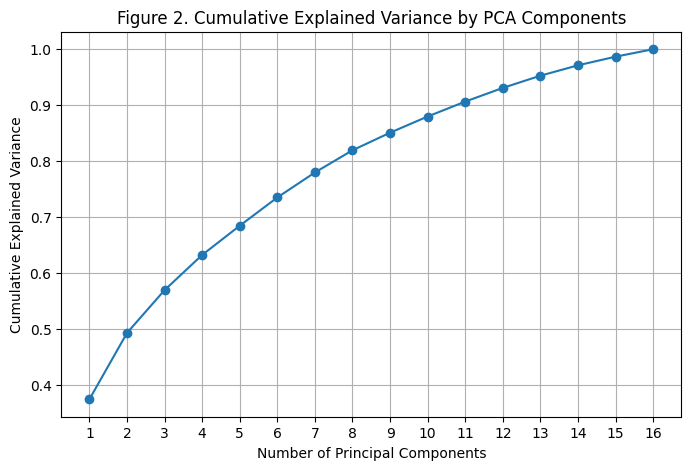

In [94]:
#Analysis 1- PCA

from sklearn.decomposition import PCA
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pca = PCA()
X_pca = pca.fit_transform(X_scaled_df)


# Create explained variance table
explained_variance = pd.DataFrame({
    "Principal Component": [f"PC{i+1}" for i in range(len(features))],
    "Explained Variance Ratio": pca.explained_variance_ratio_,
    "Cumulative Explained Variance": np.cumsum(pca.explained_variance_ratio_)
})

print(explained_variance.round(3))

#Variance Plot
plt.figure(figsize=(8, 5))

plt.plot(
    range(1, len(features) + 1),
    np.cumsum(pca.explained_variance_ratio_),
    marker="o"
)

plt.xlabel("Number of Principal Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("Figure 2. Cumulative Explained Variance by PCA Components")
plt.xticks(range(1, len(features) + 1))
plt.grid(True)

plt.show()

In [95]:
#Based on PCA results, we are choosing PCA = 5 since it is capturing 68% of the total variance

In [96]:
#Fitting PCA with 5 components and checking loadings

pca_final = PCA(n_components=5)
X_pca_final = pca_final.fit_transform(X_scaled_df)

# Create PCA scores dataframe
pca_scores = pd.DataFrame(
    X_pca_final,
    columns=["PC1", "PC2", "PC3", "PC4", "PCA5"],
    index=X_scaled_df.index
)

# Create PCA loadings dataframe
loadings = pd.DataFrame(
    pca_final.components_.T,
    columns=["PC1", "PC2", "PC3", "PC4", "PCA5"],
    index=features
)

loadings.round(3)

,PC1,PC2,PC3,PC4,PCA5
Income,0.303,0.002,0.275,-0.027,0.021
Age,0.055,0.165,0.620,0.051,0.249
Children,-0.240,0.299,0.264,0.028,-0.415
CustomerTenureDays,0.042,0.390,-0.486,0.073,0.444
Recency,0.006,0.016,0.012,0.989,-0.030
MntWines,0.305,0.203,0.114,-0.016,0.328
MntFruits,0.292,-0.072,-0.182,-0.017,-0.313
MntMeatProducts,0.333,-0.077,-0.046,0.034,0.079
MntFishProducts,0.302,-0.079,-0.173,0.002,-0.249
MntSweetProducts,0.291,-0.057,-0.163,0.033,-0.289


In [97]:
#PCA interpretation

# | Component | Strongest Loadings                                      | Interpretation                                          |
# | --------- | ------------------------------------------------------- | ------------------------------------------------------- |
# | PC1       | Income, product spending, catalog purchases             | Customer Value / Spending Intensity                     |
# | PC2       | Deal purchases, web purchases, tenure, children         | Deal-Seeking / Web-Engaged Behavior                     |
# | PC3       | Age, income, children, negative tenure                  | Older Affluent Newer Customers                          |
# | PC4       | Recency                                                 | Purchase Recency / Recent Engagement                    |
# | PC5       | Wine spending, tenure, negative children/deal purchases | Wine-Oriented Loyalty vs. Deal-Oriented Family Shopping |


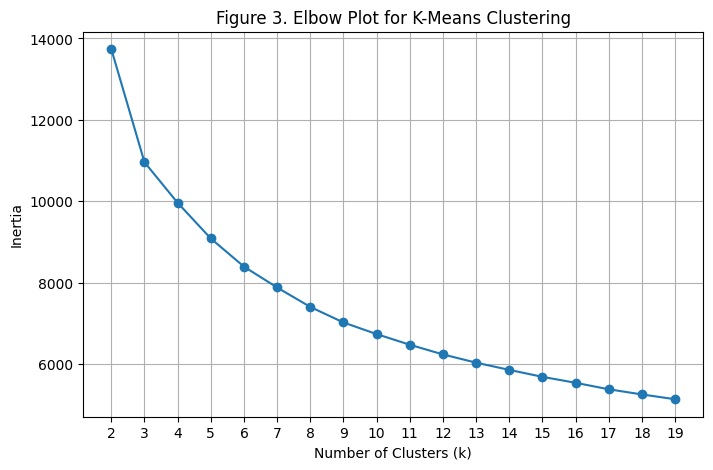

In [98]:
#Running Kmeans on 5 PCAs

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import pandas as pd
import matplotlib.pyplot as plt

cluster_results = []

for k in range(2, 20):
    kmeans = KMeans(n_clusters=k, random_state=777, n_init=25)
    labels = kmeans.fit_predict(pca_scores)

    cluster_results.append({
        "k": k,
        "Inertia": kmeans.inertia_,
        "Silhouette Score": silhouette_score(pca_scores, labels)
    })

cluster_results_df = pd.DataFrame(cluster_results)

cluster_results_df


#Elbow plot for Kmeans
plt.figure(figsize=(8, 5))

plt.plot(
    cluster_results_df["k"],
    cluster_results_df["Inertia"],
    marker="o"
)

plt.xlabel("Number of Clusters (k)")
plt.ylabel("Inertia")
plt.title("Figure 3. Elbow Plot for K-Means Clustering")
plt.xticks(cluster_results_df["k"])
plt.grid(True)

plt.show()

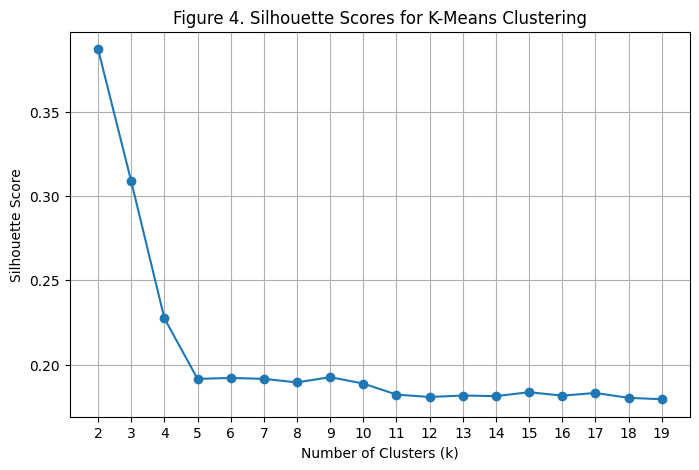

In [99]:
#Checking cluster separation for K means

plt.figure(figsize=(8, 5))

plt.plot(
    cluster_results_df["k"],
    cluster_results_df["Silhouette Score"],
    marker="o"
)

plt.xlabel("Number of Clusters (k)")
plt.ylabel("Silhouette Score")
plt.title("Figure 4. Silhouette Scores for K-Means Clustering")
plt.xticks(cluster_results_df["k"])
plt.grid(True)

plt.show()

In [100]:
#We are choosing and running 4 clusters K means based on elbow & silhouette plot

from sklearn.cluster import KMeans


kmeans_final = KMeans(n_clusters=4, random_state=777, n_init=25)
df_clean["Cluster"] = kmeans_final.fit_predict(pca_scores)
df_clean["Cluster"].value_counts().sort_index()

,count
Cluster,
0,540
1,600
2,529
3,544


In [101]:
# Cluster profile based on key customer characteristics

cluster_profile = df_clean.groupby("Cluster")[
    [
        "Income",
        "Age",
        "Children",
        "CustomerTenureDays",
        "Recency",
        "TotalSpend",
        "TotalPurchases",
        "NumDealsPurchases",
        "NumWebPurchases",
        "NumCatalogPurchases",
        "NumStorePurchases",
        "NumWebVisitsMonth",
        "TotalCampaignAccepted"
    ]
].mean().round(2)

cluster_profile

,Income,Age,Children,CustomerTenureDays,Recency,TotalSpend,TotalPurchases,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,TotalCampaignAccepted
Cluster,,,,,,,,,,,,,
0,43691.92,47.99,1.44,185.76,52.14,137.67,6.94,2.02,2.29,0.82,3.83,5.17,0.13
1,76645.10,45.65,0.24,350.15,49.25,1346.50,19.64,1.33,5.23,5.91,8.50,2.82,0.90
2,57259.12,49.23,1.21,451.40,48.13,776.03,17.41,4.10,6.63,3.14,7.64,6.20,0.49
3,28913.20,37.53,0.98,429.44,46.49,92.98,5.63,2.00,2.14,0.48,3.01,7.38,0.23


In [102]:
# Add cluster size to the profile table

cluster_size = df_clean["Cluster"].value_counts().sort_index()

cluster_profile_with_size = cluster_profile.copy()
cluster_profile_with_size.insert(0, "ClusterSize", cluster_size)

cluster_profile_with_size

,ClusterSize,Income,Age,Children,CustomerTenureDays,Recency,TotalSpend,TotalPurchases,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,TotalCampaignAccepted
Cluster,,,,,,,,,,,,,,
0,540,43691.92,47.99,1.44,185.76,52.14,137.67,6.94,2.02,2.29,0.82,3.83,5.17,0.13
1,600,76645.10,45.65,0.24,350.15,49.25,1346.50,19.64,1.33,5.23,5.91,8.50,2.82,0.90
2,529,57259.12,49.23,1.21,451.40,48.13,776.03,17.41,4.10,6.63,3.14,7.64,6.20,0.49
3,544,28913.20,37.53,0.98,429.44,46.49,92.98,5.63,2.00,2.14,0.48,3.01,7.38,0.23


In [103]:
# #Cluster Interpretation

# | Cluster | Segment Name | Key Numbers | Interpretation | Recommended Marketing Action |

# | 0 | Low-Engagement Family Customers | Income: $43,691.92; Age: 47.99; Children: 1.44; Total Spend: $137.67; Total Purchases: 6.94; Web Visits/Month: 5.17; Campaign Acceptance: 0.13
#This segment has moderate-low income, the highest number of children at home, low spending, low purchase frequency, and the weakest campaign response.
#These customers may be budget-conscious or less attached to the brand.
#Use practical value-based offers, household essentials bundles, and selective reactivation campaigns.
#Avoid over-investing premium marketing resources unless profitability improves.

# | 1 | Premium High-Value Customers | Income: $76,645.10; Age: 45.65; Children: 0.24; Total Spend: $1,346.50; Total Purchases: 19.64; Web Visits/Month: 2.82; Campaign Acceptance: 0.90
#This is the company’s strongest customer segment. They have the highest income, highest spending, highest purchase volume, and strongest campaign acceptance.
#Prioritize premium bundles, loyalty rewards, early access offers, personalized cross-sell campaigns, and VIP-style retention programs.

# | 2 | Deal-Seeking Omnichannel Families | Income: $57,259.12; Age: 49.23; Children: 1.21; Total Spend: $776.03; Total Purchases: 17.41; Deal Purchases: 4.10; Web Purchases: 6.63; Store Purchases: 7.64; Campaign Acceptance: 0.49
#This segment is valuable but promotion-sensitive. They purchase frequently, use multiple channels, and have the highest number of deal purchases.
#Use personalized coupons, loyalty points, family-oriented bundles, targeted promotions, and online-to-store campaigns.



# | 3 | Young Digital Browsers / Low Converters | Income: $28,913.20; Age: 37.53; Children: 0.98; Total Spend: $92.98; Total Purchases: 5.63; Web Visits/Month: 7.38; Campaign Acceptance: 0.23
#This group is younger and lower-income, with the lowest spending and purchase activity, but the highest monthly web visits.
#They are digitally engaged but not converting strongly.
#Use retargeting, welcome offers, browse-abandonment emails, entry-level product offers, and digital conversion campaigns.

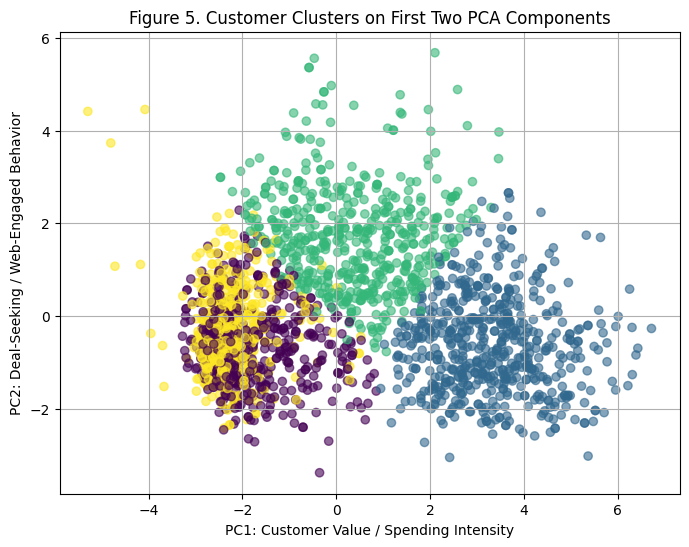

In [104]:
#Cluster Chart- PCA 1 vs 2
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))

plt.scatter(
    pca_scores["PC1"],
    pca_scores["PC2"],
    c=df_clean["Cluster"],
    alpha=0.6
)

plt.xlabel("PC1: Customer Value / Spending Intensity")
plt.ylabel("PC2: Deal-Seeking / Web-Engaged Behavior")
plt.title("Figure 5. Customer Clusters on First Two PCA Components")
plt.grid(True)

plt.show()

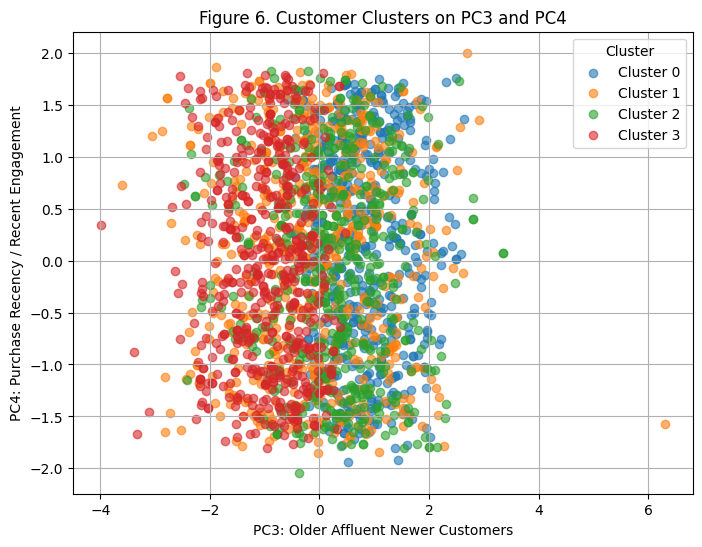

In [105]:
#Cluster Chart- PCA 3 vs 4
pca_plot_df = pca_scores.copy()
pca_plot_df["Cluster"] = df_clean["Cluster"]

plt.figure(figsize=(8, 6))

for cluster in sorted(pca_plot_df["Cluster"].unique()):
    cluster_data = pca_plot_df[pca_plot_df["Cluster"] == cluster]

    plt.scatter(
        cluster_data["PC3"],
        cluster_data["PC4"],
        alpha=0.6,
        label=f"Cluster {cluster}"
    )

plt.xlabel("PC3: Older Affluent Newer Customers")
plt.ylabel("PC4: Purchase Recency / Recent Engagement")
plt.title("Figure 6. Customer Clusters on PC3 and PC4")
plt.legend(title="Cluster")
plt.grid(True)

plt.show()